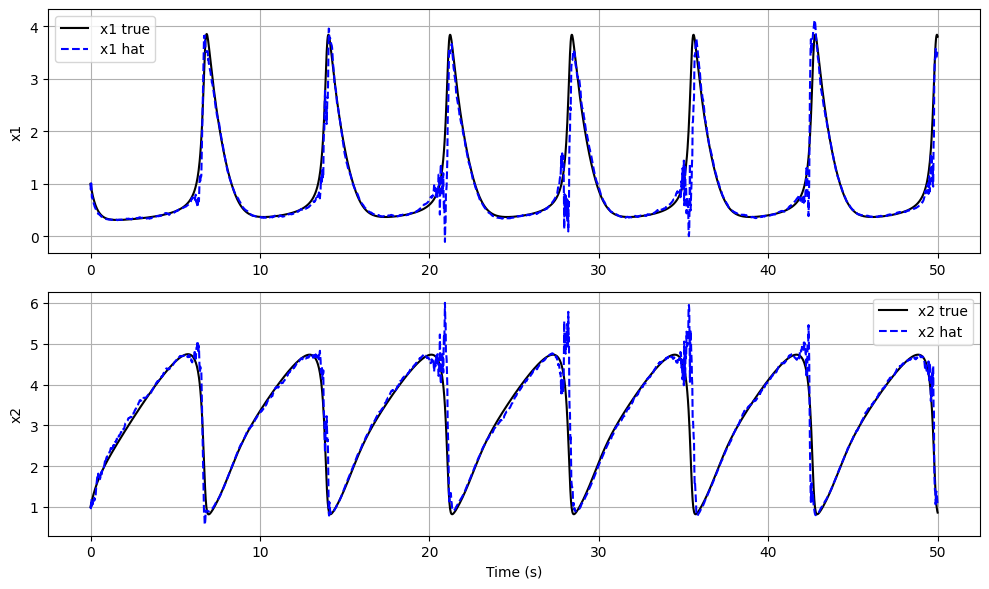

RMS Error x1: 0.2917
RMS Error x2: 0.3578


In [1]:
import numpy as np
from matplotlib import pyplot as plt

class ExtendedKalman:
    def __init__(self, f, h, Q, R, x_0, P_0, t_0=.0, F=None, H=None):
        self.f = f
        self.h = h
        self.Q = Q
        self.R = R
        self.x = x_0
        self.P = P_0
        self.t = t_0
        self.F = lambda x, u, t: self._jacobian(f, x, u, t) if F is None else F
        self.H = lambda x, u, t: self._jacobian(h, x, u, t) if H is None else H

    def step(self, u, dt):
        x, P, t = self.x, self.P, self.t
        x_dot = lambda x, t: self.f(x, u, t)
        P_dot = lambda P, x, t: self.F(x, u, t) @ P + P @ self.F(x, u, t).T + self.Q

        k1_x = x_dot(x, t)
        k1_P = P_dot(P, x, t)
        k2_x = x_dot(x + dt/2 * k1_x, t + dt/2)
        k2_P = P_dot(P + dt/2 * k1_P, x + dt/2 * k1_x, t + dt/2)
        k3_x = x_dot(x + dt/2 * k2_x, t + dt/2)
        k3_P = P_dot(P + dt/2 * k2_P, x + dt/2 * k2_x, t + dt/2)
        k4_x = x_dot(x + dt * k3_x, t + dt)
        k4_P = P_dot(P + dt * k3_P, x + dt * k3_x, t + dt)

        self.x = x + dt/6 * (k1_x + 2*k2_x + 2*k3_x + k4_x)
        self.P = P + dt/6 * (k1_P + 2*k2_P + 2*k3_P + k4_P)
        self.t += dt

        return self.x, self.P

    def measurement(self, z, u, max_i=5, eps=1e-6):
        x, P, t = self.x, self.P, self.t
        new_x = x
        H = None

        for _ in range(max_i):
            H = self.H(new_x, u, t)
            temp = H @ P @ H.T + self.R
            K = P @ H.T @ np.linalg.inv(temp)
            new_x = x + K @ (z - self.h(new_x, u, t) - H @ (x - new_x))
            if np.max(np.abs(new_x - x)) <= eps:
                break

        I = np.eye(len(P))
        new_P = (I - K @ H) @ P

        self.x = new_x
        self.P = new_P
        return new_x, new_P

    def _jacobian(self, f, x, u, t, eps=1e-4):
        f0 = f(x, u, t)
        n = len(x)
        m = len(f0)
        J = np.zeros((m, n))

        for i in range(n):
            x_eps = x.copy()
            x_eps[i, 0] += eps
            f_eps = f(x_eps, u, t)
            J[:, i] = (f_eps[:, 0] - f0[:, 0]) / eps

        return J

def rk4(f, x, t, dt):
    k1 = f(x, t)
    k2 = f(x + dt/2 * k1, t + dt/2)
    k3 = f(x + dt/2 * k2, t + dt/2)
    k4 = f(x + dt * k3, t + dt)
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rms_error(x_true, x_est):
    return np.sqrt(np.mean((x_true - x_est)**2))

if __name__ == '__main__':
    dt = 0.02
    T = 50.0
    t = np.linspace(0, T, int(T/dt)+1)

    # Nonlinear dynamics from the image
    def f(x, u, t):
        x1 = x[0, 0]
        x2 = x[1, 0]
        dx1 = 1 + x1**2 * x2 - 4 * x1
        dx2 = 3 * x1 - x1**2 * x2
        return np.array([[dx1], [dx2]])

    def h(x, u, t):
        return np.array([[x[0, 0] + x[1, 0]]])

    # Process and measurement noise
    q = 0.01
    Q = q * np.eye(2)
    r = 1
    R = np.array([[r]])

    # Initial state
    x0 = np.array([[1.0], [1.0]])
    P0 = np.eye(2)

    # Simulate ground truth
    x_true = np.zeros((len(t), 2, 1))
    x_true[0] = x0
    for i in range(len(t)-1):
        # x_true[i+1] = rk4(lambda x, t: f(x, None, t), x_true[i], t[i], dt)
        x_true[i+1] = x_true[i] + dt * f(x_true[i], None, t[i])

    # Generate measurements y = x1 + x2 + noise
    z = np.zeros((len(t), 1))
    for i in range(len(t)):
        y_true = x_true[i, 0, 0] + x_true[i, 1, 0]
        z[i] = y_true + np.random.normal(0, np.sqrt(r))

    # Run EKF
    ekf = ExtendedKalman(f, h, Q, R, x0.copy(), P0.copy())
    x_est = np.zeros((len(t), 2, 1))
    x_est[0] = x0

    u = np.array([[0.0]])  # no input
    for i in range(1, len(t)):
        ekf.step(u, dt)
        x_est[i], _ = ekf.measurement(z[i], u)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t, x_true[:, 0, 0], 'k-', label='x1 true')
    plt.plot(t, x_est[:, 0, 0], 'b--', label='x1 hat')
    plt.legend()
    plt.grid(True)
    plt.ylabel('x1')

    plt.subplot(2, 1, 2)
    plt.plot(t, x_true[:, 1, 0], 'k-', label='x2 true')
    plt.plot(t, x_est[:, 1, 0], 'b--', label='x2 hat')
    plt.legend()
    plt.grid(True)
    plt.ylabel('x2')
    plt.xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

    # Report RMS error
    rms_x1 = rms_error(x_true[:, 0, 0], x_est[:, 0, 0])
    rms_x2 = rms_error(x_true[:, 1, 0], x_est[:, 1, 0])
    print(f"RMS Error x1: {rms_x1:.4f}")
    print(f"RMS Error x2: {rms_x2:.4f}")


In [2]:
import numpy as np

def rms_error(a, b):
    return np.sqrt(np.mean((a - b)**2))

# اگر بخوای RMS خطای کل هر دو بردار رو با هم حساب کنی:
rms_total = np.sqrt(np.mean(np.sum((x_true[:, :, 0] - x_est[:, :, 0])**2, axis=1)))

# یا اگر جداگانه برای x1 و x2 بخوای:
rms_x1 = rms_error(x_true[:, 0, 0], x_est[:, 0, 0])
rms_x2 = rms_error(x_true[:, 1, 0], x_est[:, 1, 0])

rms_total

0.46165303024852344